In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cv2
import os
import glob
from analyze_videos import*
from frazil_analysis_Icefin import*
%load_ext autoreload
%autoreload 2
%matplotlib inline
    
import os, sys
sys.path.append(os.getcwd())
os.chdir("../../..")
savedir = os.path.join(os.getcwd(),"DATA")
path = os.getcwd()
path = os.path.join(path,"DATA/SIOS21/")

path_p = path + "MARS_ICE02_034/MARS_ICE02_034_CSV/"
# file1 = "MARS_ICE02_032_telemetry.gssbin_OPENINS_PRESSURE_STAT.csv"
file_p = "MARS_ICE02_034_1_telemetry.gssbin_OPENINS_PRESSURE_STAT.nc"
path_v = path + "MARS_ICE02_034/"
file_v_t = "video_timing_UTC.csv" # video timing
# processed frazil sizes
path_s = path + "MARS_ICE02_034/netcdf_frazil_data/frazil_sizes"
# parse the csv file of the pressure data
ds_icefin = xr.open_dataset(path_p + file_p, engine = "netcdf4")
# parse the csv file of the video timing
video_timing = pd.read_csv(path_v + file_v_t)
netcdf_path = os.path.join(path_v, "netcdf_frazil_data")

bar length  2880.0  frames
[ 10.49673411 112.27352792 160.14120277 159.94451336]
frames selected at  [15.5 20.  24.5 29. ] minutes into the video
MARS_ICE02_034_1_box_4_1635903774_65071511[0000].mov


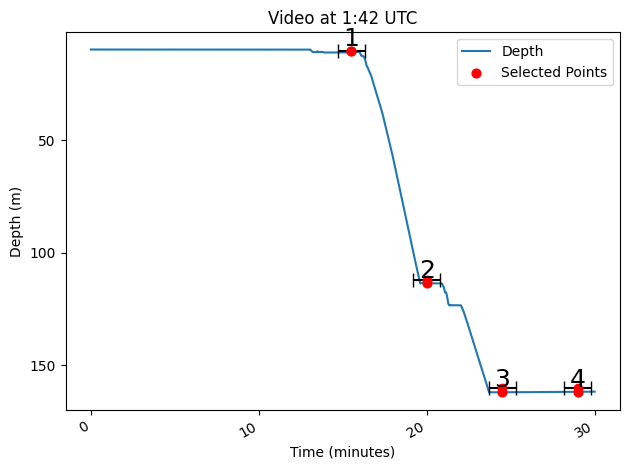

In [2]:
# plot first video trajectory
video_number = 1
start_time_minutes = 15.5
end_time_minutes = 29.

time_sel, depth_sel = four_epochs_analysis(ds_icefin, video_timing, video_number, start_time_minutes, end_time_minutes)
print("frames selected at ",time_sel, "minutes into the video")
# select timing with equal spacing to match the ramps
video_file = video_timing["box4 file name"][video_number]
print(video_file)

# for i in range(len(time_sel)):
#     start_time = time_sel[i]
#     extract_frames_period(path_v, "video_1.mp4", start_time) ## FIX-ME: this function got corrupted along the way and does not extract frames
# print("start time for ADCP comparison", pd.Timedelta(time_sel[0], "minutes")+pd.to_datetime(video_timing["box4 start (UTC)"][video_number]))

In [3]:
print("FIRST VIDEO")
print("FRAGMENT 1")
# SIZES
video_file = "MARS_ICE02_034_1_box_4_1635903774_65071511[0000].mov"
start_time = 15.5
ds_sizes = frazil_spectrum(path_v, video_file, start_time, retrieval_mode="RETR_TREE")
ds_sizes
# CONCENTRATIONS
fs1 = analyze_IcefinCam(ds_sizes, tau=1/30, max_range=60.0, bin_width=1e-3)
fs1 = fs1.assign_coords(depth=[depth_sel[0]])
print("Mean concentration ", fs1.meanFIC.data, " m3/m3")
print("Mean size ", fs1.meanD.data*1e3, " mm")
print("FRAGMENT 2")
video_file = "MARS_ICE02_034_1_box_4_1635903774_65071511[0000].mov"
start_time = 20.0
ds_sizes = frazil_spectrum(path_v, video_file, start_time, retrieval_mode="RETR_TREE")
# CONCENTRATIONS
fs2 = analyze_IcefinCam(ds_sizes, tau=1/30, max_range=60.0, bin_width=1e-3)
fs2 = fs2.assign_coords(depth=[depth_sel[1]])
fs = xr.concat([fs1, fs2], dim="depth")
print("Mean concentration ", fs2.meanFIC.data, " m3/m3")
print("Mean size ", fs2.meanD.data*1e3, " mm")
print("FRAGMENT 3")
# SIZES
video_file = "MARS_ICE02_034_1_box_4_1635903774_65071511[0000].mov"
start_time = 24.5
ds_sizes = frazil_spectrum(path_v, video_file, start_time, retrieval_mode="RETR_TREE")
# CONCENTRATIONS
fs2 = analyze_IcefinCam(ds_sizes, tau=1/30, max_range=60.0, bin_width=1e-3)
fs2 = fs2.assign_coords(depth=[depth_sel[2]])
fs = xr.concat([fs, fs2], dim="depth")
print("Mean concentration ", fs2.meanFIC.data, " m3/m3")
print("Mean size ", fs2.meanD.data*1e3, " mm")
print("FRAGMENT 4")
# SIZES
video_file = "MARS_ICE02_034_1_box_4_1635903774_65071511[0000].mov"
start_time = 29.0
ds_sizes = frazil_spectrum(path_v, video_file, start_time, retrieval_mode="RETR_TREE")
# CONCENTRATIONS
fs2 = analyze_IcefinCam(ds_sizes, tau=1/30, max_range=60.0, bin_width=1e-3)
fs2 = fs2.assign_coords(depth=[depth_sel[3]])
fs = xr.concat([fs, fs2], dim="depth")
print("Mean concentration ", fs2.meanFIC.data, " m3/m3")
print("Mean size ", fs2.meanD.data*1e3, " mm")

FIRST VIDEO
FRAGMENT 1
Mean concentration  [3.36878524e-05]  m3/m3
Mean size  [6.57071246]  mm
FRAGMENT 2
Mean concentration  [7.26046734e-07]  m3/m3
Mean size  [8.33790008]  mm
FRAGMENT 3


/tmp/ipykernel_2500272/517719100.py:20: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  fs = xr.concat([fs1, fs2], dim="depth")


Mean concentration  [6.16715515e-07]  m3/m3
Mean size  [7.28714206]  mm
FRAGMENT 4
Mean concentration  [3.3640793e-06]  m3/m3
Mean size  [8.44029284]  mm


bar length  2880.0  frames
[69.94414446 49.72117633 29.36219762 19.41219814]
frames selected at  [ 0.9        10.26666667 19.63333333 29.        ] minutes into the video
MARS_ICE02_034_1_box_4_1635907401_79831195[0000].mov


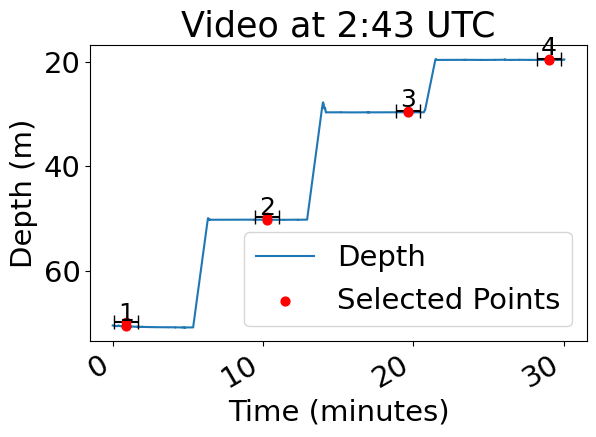

In [4]:
# SECOND VIDEO
video_number = 3
time_sel, depth_sel = four_epochs_analysis(ds_icefin, video_timing, video_number, 0.9, 29.)
print("frames selected at ",time_sel, "minutes into the video")
# select timing with equal spacing to match the ramps
video_file = video_timing["box4 file name"][video_number]
print(video_file)

# for i in range(len(time_sel)):
#     start_time = time_sel[i]
#     extract_frames_period(path_v, video_file, start_time)
# print("end time for ADCP comparison", pd.Timedelta(time_sel[-1], "minutes")+pd.Timedelta(1439/30, "seconds")+pd.to_datetime(video_timing["box4 start (UTC)"][video_number]))

In [5]:
print("SECOND VIDEO")
print("FRAGMENT 1")
# SIZES
video_file = "MARS_ICE02_034_1_box_4_1635907401_79831195[0000].mov"
start_time = 0.9
ds_sizes = frazil_spectrum(path_v, video_file, start_time, retrieval_mode="RETR_TREE")
# CONCENTRATIONS
fs1 = analyze_IcefinCam(ds_sizes, tau=1/30, max_range=60.0, bin_width=1e-3)
fs1 = fs1.assign_coords(depth=[depth_sel[0]])
print("Mean concentration ", fs1.meanFIC.data, " m3/m3")
print("Mean size ", fs1.meanD.data*1e3, " mm")
print("FRAGMENT 2")
# SIZES
video_file = "MARS_ICE02_034_1_box_4_1635907401_79831195[0000].mov"
start_time = 10.266666666666667
ds_sizes = frazil_spectrum(path_v, video_file, start_time, retrieval_mode="RETR_TREE")
# CONCENTRATIONS
fs2 = analyze_IcefinCam(ds_sizes, tau=1/30, max_range=60.0, bin_width=1e-3)
fs2 = fs2.assign_coords(depth=[depth_sel[1]])
fs = xr.concat([fs, fs1, fs2], dim="depth")
print("Mean concentration ", fs2.meanFIC.data, " m3/m3")
print("Mean size ", fs2.meanD.data*1e3, " mm")
print("FRAGMENT 3")
# SIZES
video_file = "MARS_ICE02_034_1_box_4_1635907401_79831195[0000].mov"
start_time = 19.633333333333333
ds_sizes = frazil_spectrum(path_v, video_file, start_time, retrieval_mode="RETR_TREE")
# CONCENTRATIONS
fs2 = analyze_IcefinCam(ds_sizes, tau=1/30, max_range=60.0, bin_width=1e-3)
fs2 = fs2.assign_coords(depth=[depth_sel[2]])
fs = xr.concat([fs, fs2], dim="depth")
print("Mean concentration ", fs2.meanFIC.data, " m3/m3")
print("Mean size ", fs2.meanD.data*1e3, " mm")
print("FRAGMENT 4")
# SIZES
video_file = "MARS_ICE02_034_1_box_4_1635907401_79831195[0000].mov"
start_time = 29.0
ds_sizes = frazil_spectrum(path_v, video_file, start_time, retrieval_mode="RETR_TREE")
# CONCENTRATIONS
fs2 = analyze_IcefinCam(ds_sizes, tau=1/30, max_range=60.0, bin_width=1e-3)
fs2 = fs2.assign_coords(depth=[depth_sel[3]])
fs = xr.concat([fs, fs2], dim="depth")
print("Mean concentration ", fs2.meanFIC.data, " m3/m3")
print("Mean size ", fs2.meanD.data*1e3, " mm")

SECOND VIDEO
FRAGMENT 1
Mean concentration  [2.74902539e-07]  m3/m3
Mean size  [6.19545825]  mm
FRAGMENT 2
Mean concentration  [1.47275861e-07]  m3/m3
Mean size  [4.96117063]  mm
FRAGMENT 3
Mean concentration  [6.65519817e-08]  m3/m3
Mean size  [4.00721637]  mm
FRAGMENT 4
Mean concentration  [1.01333959e-07]  m3/m3
Mean size  [4.77949758]  mm


In [6]:
fs = fs.sortby("depth")
if not os.path.exists(os.path.join(netcdf_path,"MARS_ICE02_034_1_box_4_thresh_40_stats_all.nc")):
    fs.to_netcdf(os.path.join(netcdf_path,"MARS_ICE02_034_1_box_4_thresh_40_stats_all.nc"), engine="netcdf4")

In [7]:
fs.meanFIC

<xarray.DataArray 'meanFIC' (depth: 8)> Size: 64B
array([3.36878524e-05, 1.01333959e-07, 6.65519817e-08, 1.47275861e-07,
       2.74902539e-07, 7.26046734e-07, 3.36407930e-06, 6.16715515e-07])
Coordinates:
  * depth    (depth) float64 64B 10.5 19.41 29.36 49.72 69.94 112.3 159.9 160.1

Text(0, 0.5, 'Depth (m)')

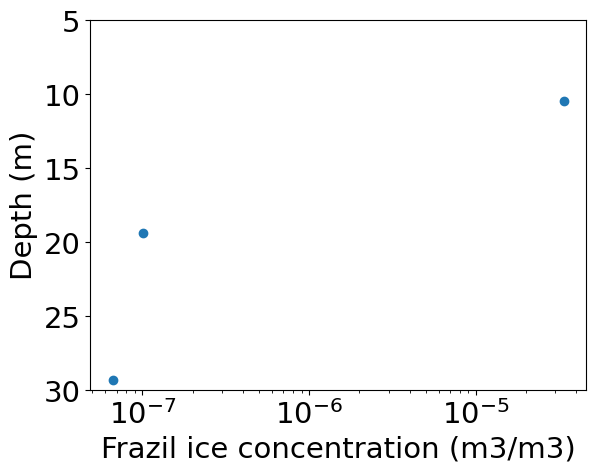

In [8]:
fig, ax = plt.subplots()
ax.scatter(fs.meanFIC, fs.depth)
ax.set_ylim([5,30])
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("Frazil ice concentration (m3/m3)")
ax.set_ylabel("Depth (m)")

Text(0, 0.5, 'PDF')

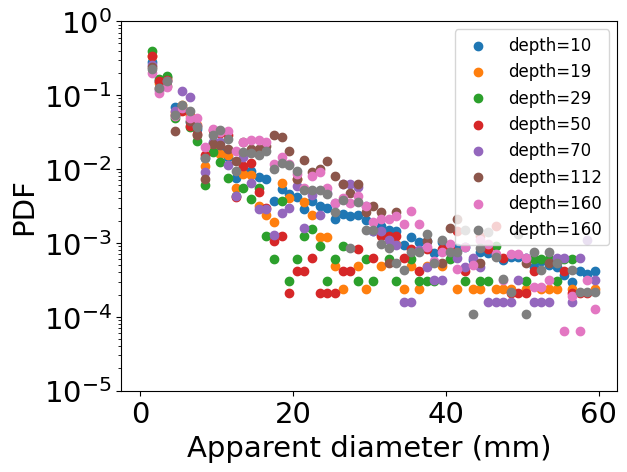

In [9]:
fig,ax = plt.subplots()
for i in range(len(fs.depth)):
    ax.scatter(fs.diameter*1e3, fs.normalized_numbers.data[i,:], label="depth="+str(int(np.round(fs.depth[i].data,0))))
ax.set_yscale('log')
ax.set_ylim([1e-5, 1])
ax.legend(fontsize=12)
ax.set_xlabel("Apparent diameter (mm)")
ax.set_ylabel("PDF")

Text(0, 0.5, 'Frazil ice concentration (m3/m3)')

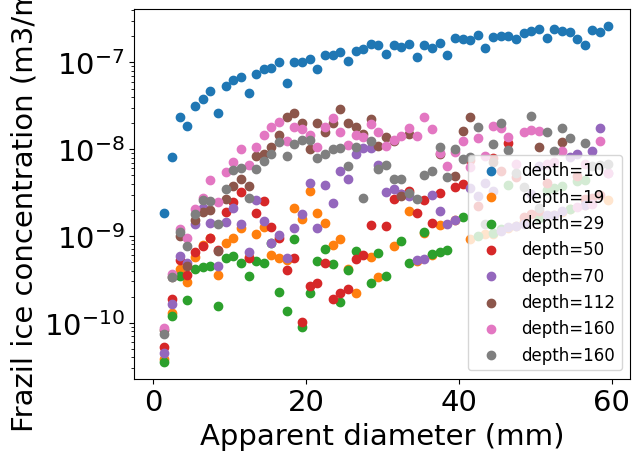

In [10]:
fig,ax = plt.subplots()
for i in range(len(fs.depth)):
    ax.scatter(fs.diameter*1e3, fs.volume_distribution.data[i,:], label="depth="+str(int(np.round(fs.depth[i].data,0))))
ax.set_yscale('log')
# ax.set_ylim([1e-5, 1])
ax.legend(fontsize=12)
ax.set_xlabel("Apparent diameter (mm)")
ax.set_ylabel("Frazil ice concentration (m3/m3)")